Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB

Missing Values in Each Column:
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education

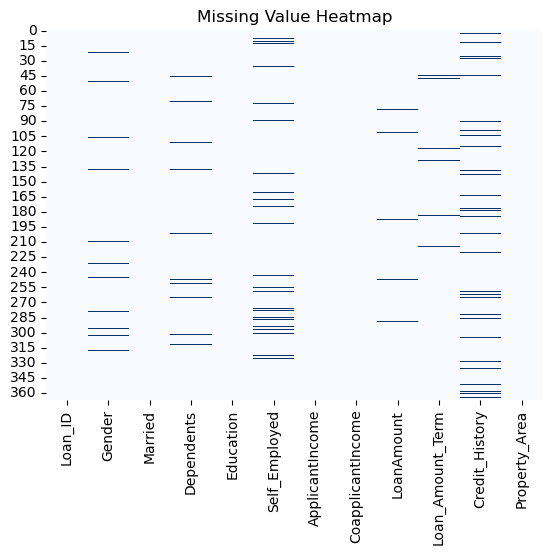


Missing Values After Handling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Removed 0 duplicate rows.

Dependents Data Type:
int32

Categorical values standardized successfully.

Min-Max Normalization completed.
Credit_History Standardization completed.

Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    int32  
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,0.078865,0.000000,0.157088,360.0,0.437674,Urban
1,LP001022,Male,Yes,1,Graduate,No,0.042411,0.062500,0.187739,360.0,0.437674,Urban
2,LP001031,Male,Yes,2,Graduate,No,0.068938,0.075000,0.344828,360.0,0.437674,Urban
3,LP001035,Male,Yes,2,Graduate,No,0.032263,0.106083,0.137931,360.0,0.437674,Urban
4,LP001051,Male,No,0,Not graduate,No,0.045168,0.000000,0.095785,360.0,0.437674,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3,Not graduate,Yes,0.055274,0.074042,0.162835,360.0,0.437674,Urban
363,LP002975,Male,Yes,0,Graduate,No,0.057329,0.029542,0.166667,360.0,0.437674,Urban
364,LP002980,Male,No,0,Graduate,No,0.044810,0.083042,0.187739,360.0,0.437674,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,0.068938,0.099708,0.249042,360.0,0.437674,Rural



Cleaned dataset saved successfully as 'cleaned_loan_dataset.csv'


In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler


# Load the dataset
df = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')


# Display basic information
print("Initial Data Overview:")
df.info()


# 1. Handling Missing Values

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Missing value heatmap
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()


# Fill missing categorical values with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill LoanAmount with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Fill Loan_Amount_Term with mode
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)

# Fill Credit_History with mode
df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


# 2. Removing Duplicates

initial_rows = df.shape[0]

df.drop_duplicates(inplace=True)

print(f"\nRemoved {initial_rows - df.shape[0]} duplicate rows.")


# 3. Data Type Conversion

# Convert '3+' to 3
df['Dependents'] = df['Dependents'].replace('3+', 3)

# Fill any remaining missing values
df['Dependents'] = df['Dependents'].fillna(0)

# Convert Dependents to integer
df['Dependents'] = df['Dependents'].astype(int)

print("\nDependents Data Type:")
print(df['Dependents'].dtype)


# 4. Ensuring Categorical Consistency

for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']:
    df[col] = df[col].str.strip().str.capitalize()

print("\nCategorical values standardized successfully.")


# 5. Normalization

min_max_scaler = MinMaxScaler()

scale_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

df[scale_cols] = min_max_scaler.fit_transform(df[scale_cols])

print("\nMin-Max Normalization completed.")


# 6. Standardization

scaler = StandardScaler()

df[['Credit_History']] = scaler.fit_transform(
    df[['Credit_History']]
)

print("Credit_History Standardization completed.")


# 7. Final Overview

print("\nCleaned Data Summary:")
df.info()

print("\nFirst 5 Rows of Cleaned Dataset:")
print(df.head())


# 8. Final Missing Value Check

print("\nFinal Missing Values:")
print(df.isnull().sum())


# 9. Final Dataset Shape

print("\nFinal Dataset Shape:")
print(df.shape)


# 10. Display Complete Cleaned Dataset

print("\nComplete Cleaned Dataset:")
display(df)


# 11. Save Cleaned Dataset

df.to_csv('cleaned_loan_dataset.csv', index=False)

print("\nCleaned dataset saved successfully as 'cleaned_loan_dataset.csv'")